# Introduction to LangChain and LangGraph

## What is LangChain?
**LangChain** is an open-source orchestration framework designed to simplify the creation of applications using Large Language Models (LLMs). It provides a standard interface for chains, integration with various tools/LLMs, and pre-built components for common LLM workflows like retrieval-augmented generation (RAG) and conversational agents.

## What is LangGraph?
**LangGraph** is a library built on top of LangChain specifically designed to build **stateful, multi-actor applications with cyclic graphs** (i.e. agentic workflows). While LangChain lets you define linear chains of computation, LangGraph introduces the ability to add loops (cycles) and manage state explicitly, which is crucial for sophisticated agent patterns.

## When and Why to Use Them?
- **Use LangChain** when your workflow is linear, structured, and predictable. Examples include translating text, answering questions from a document database (simple RAG), or parsing structured data.
- **Use LangGraph** when you need **loops** (e.g., an agent runs a tool, looks at the results, and decides if it needs to run another tool or ask for clarification), multi-agent collaboration, or precise control over state transition and human-in-the-loop interactions.

## Pros and Cons

### LangChain
- **Pros:**
  - Easy to get started with basic LLM chains.
  - Massive ecosystem of integrations (databases, vector stores, API tools).
  - Excellent for RAG and standard retrieval flows.
- **Cons:**
  - Hard to build cyclic/looping agent workflows.
  - State management can become complex or implicit in advanced applications.

### LangGraph
- **Pros:**
  - Built-in support for cycles/loops and graph-based workflow design.
  - Built-in state persistence, session support, and time-travel debugging.
  - Seamless support for "human-in-the-loop" approval steps.
- **Cons:**
  - Steeper learning curve than standard LangChain.
  - Adds architectural complexity for simple, linear applications.

In [39]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [49]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "llama-3.1-8b-instant")

In [41]:
from pydantic import BaseModel, Field
from typing import  Annotated
from langgraph.graph.message import add_messages

class ChatBotState(BaseModel):
    messages: Annotated[list, add_messages]
    count: int = Field( description="count of messages")

In [48]:

# Create node

def chatbot_llm(state:ChatBotState):
    result = llm.invoke(state.messages)
    return { "messages": result, "count": state.count + 1 }

In [43]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(ChatBotState)

In [44]:
from langgraph.graph import START, END

graph_builder.add_node("chatbot_llm", chatbot_llm)

graph_builder.add_edge(START, "chatbot_llm")
graph_builder.add_edge("chatbot_llm", END )


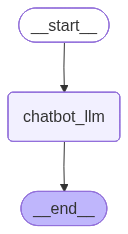

In [45]:
graph = graph_builder.compile()

graph

In [47]:

response = graph.invoke({"messages": "Hi", "count": 0})

response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='e1b6a7c1-37df-4cb8-80dc-da41a3b77954'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.022907963, 'completion_tokens_details': None, 'prompt_time': 0.002029762, 'prompt_tokens_details': None, 'queue_time': 0.048893998, 'total_time': 0.024937725}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee503-d92d-7832-aeb1-9733ad436cd6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})],
 'count': 0}